# BITS Pilani Work Integrated Learning Programme

# AIMLCZG565 – Machine Learning

# Assignment 2

# Dry Bean Classification using Machine Learning

---

### Student Name
Mansi Jain

### Student ID
2025AC05151

### Course
M.Tech Artificial Intelligence & Machine Learning

### Dataset
Dry Bean Dataset (UCI Machine Learning Repository)

### Problem Type
Multi-Class Classification


# Table of Contents

1. Introduction
2. Problem Statement
3. Dataset Description
4. Import Libraries
5. Load Dataset
6. Dataset Overview
7. Exploratory Data Analysis
8. Data Preprocessing
9. Model Building
   - Logistic Regression
   - Decision Tree
   - KNN
   - Gaussian Naive Bayes
   - Random Forest
10. Feature Importance
11. Model Comparison
12. Results and Discussion
13. Conclusion
14. Future Scope

# 1. Problem Statement

The objective of this project is to classify dry bean varieties using machine learning algorithms.

The Dry Bean Dataset contains physical and geometric characteristics extracted from images of dry beans belonging to seven different varieties.

The goal is to develop multiple supervised classification models capable of accurately identifying the bean variety and compare their performance using various evaluation metrics including:

- Accuracy
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)
- ROC-AUC

The best performing model will be selected based on comprehensive evaluation.

# 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import RandomForestClassifier

import joblib

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
import time

start_time = time.time()

# 3. Load Dataset

In [3]:
# 3. Load Dataset

In [4]:
filepath="https://raw.githubusercontent.com/mansijain56-oss/dry-bean-classification/main/Dry_Bean_Dataset.xlsx"
df = pd.read_excel(filepath)

print("Dataset Loaded Successfully")

print("\nShape of Dataset :", df.shape)

display(df.head())

Dataset Loaded Successfully

Shape of Dataset : (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


# 4. Dataset Description

The Dry Bean Dataset is obtained from the UCI Machine Learning Repository.

### Dataset Summary

| Attribute | Value |
|-----------|--------|
| Dataset Name | Dry Bean Dataset |
| Number of Records | 13,611 |
| Number of Features | 16 Numerical Features |
| Target Variable | Class |
| Number of Classes | 7 |

### Bean Classes

- BARBUNYA
- BOMBAY
- CALI
- DERMASON
- HOROZ
- SEKER
- SIRA

# 5. Dataset Overview

In [5]:
print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print("\n")

display(df.describe().T)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  objec

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


In [6]:
print("="*60)
print("Missing Values")
print("="*60)

display(df.isnull().sum())

print("\n")

print("="*60)
print("Duplicate Records")
print("="*60)

print(df.duplicated().sum())

Missing Values


,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0




Duplicate Records
68


In [7]:
print("="*60)
print("Class Distribution")
print("="*60)

display(df["Class"].value_counts())

Class Distribution


,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps in understanding the structure, distribution, and relationships within the dataset before applying machine learning algorithms.

The following analyses are performed:

- Class Distribution
- Feature Distribution
- Correlation Analysis
- Outlier Detection
- Pairwise Relationships
- Feature Statistics

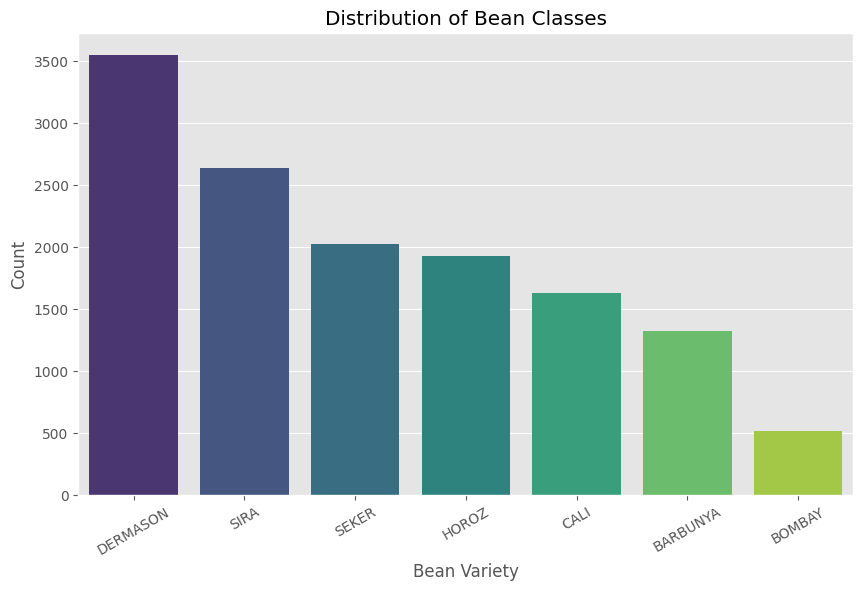

In [8]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Class",
    order=df["Class"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Bean Classes")
plt.xlabel("Bean Variety")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.show()

### Observation

- The dataset contains seven bean varieties.
- The dataset is moderately balanced.
- DERMASON contains the highest number of observations.
- BOMBAY has comparatively fewer samples.

In [9]:
class_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(class_percentage)

,proportion
Class,
DERMASON,26.05
SIRA,19.37
SEKER,14.89
HOROZ,14.17
CALI,11.98
BARBUNYA,9.71
BOMBAY,3.84


### Observation

The percentage distribution indicates that all classes are reasonably represented, making the dataset suitable for multiclass classification.

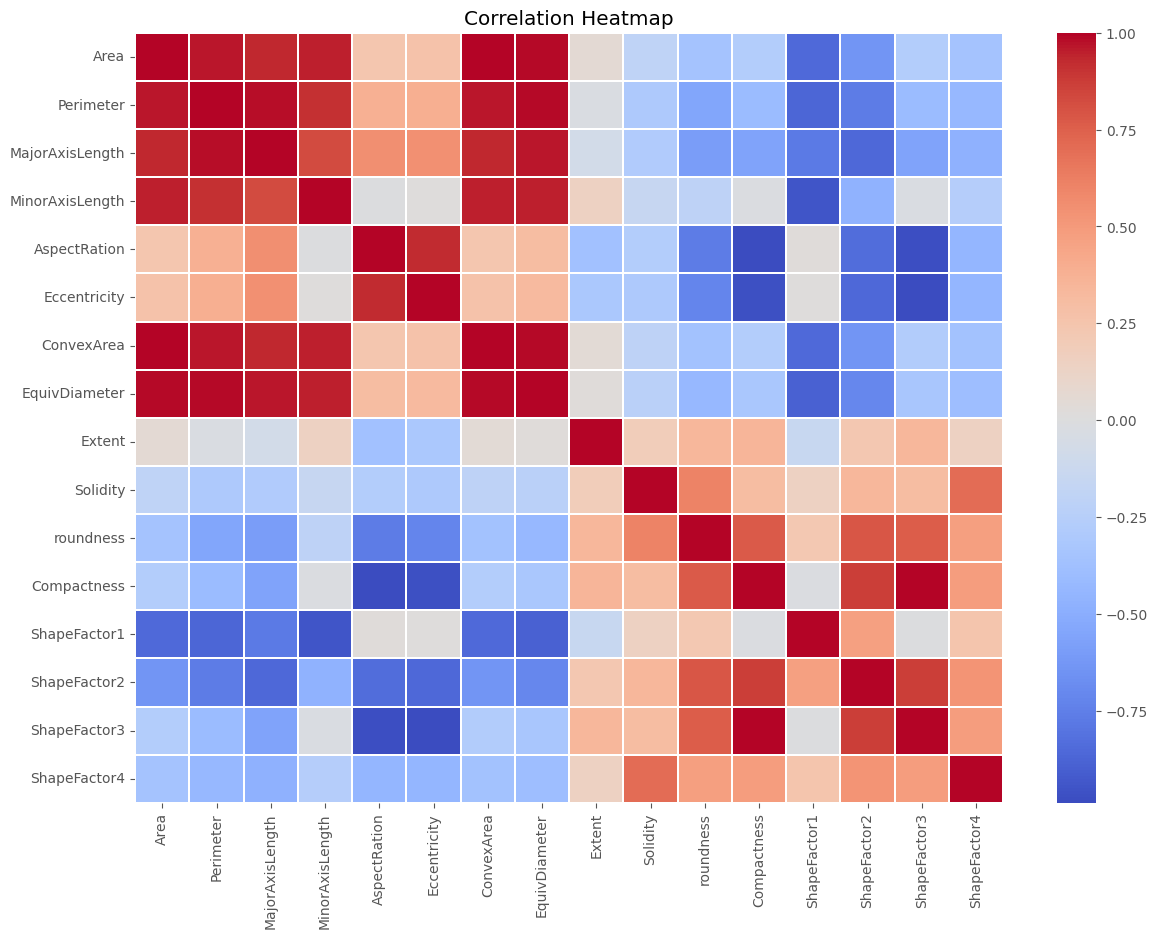

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.drop("Class", axis=1).corr(),
    cmap="coolwarm",
    annot=False,
    linewidths=0.3
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Several geometric features show strong positive correlation because they are derived from the same bean dimensions. Highly correlated features may provide similar information.

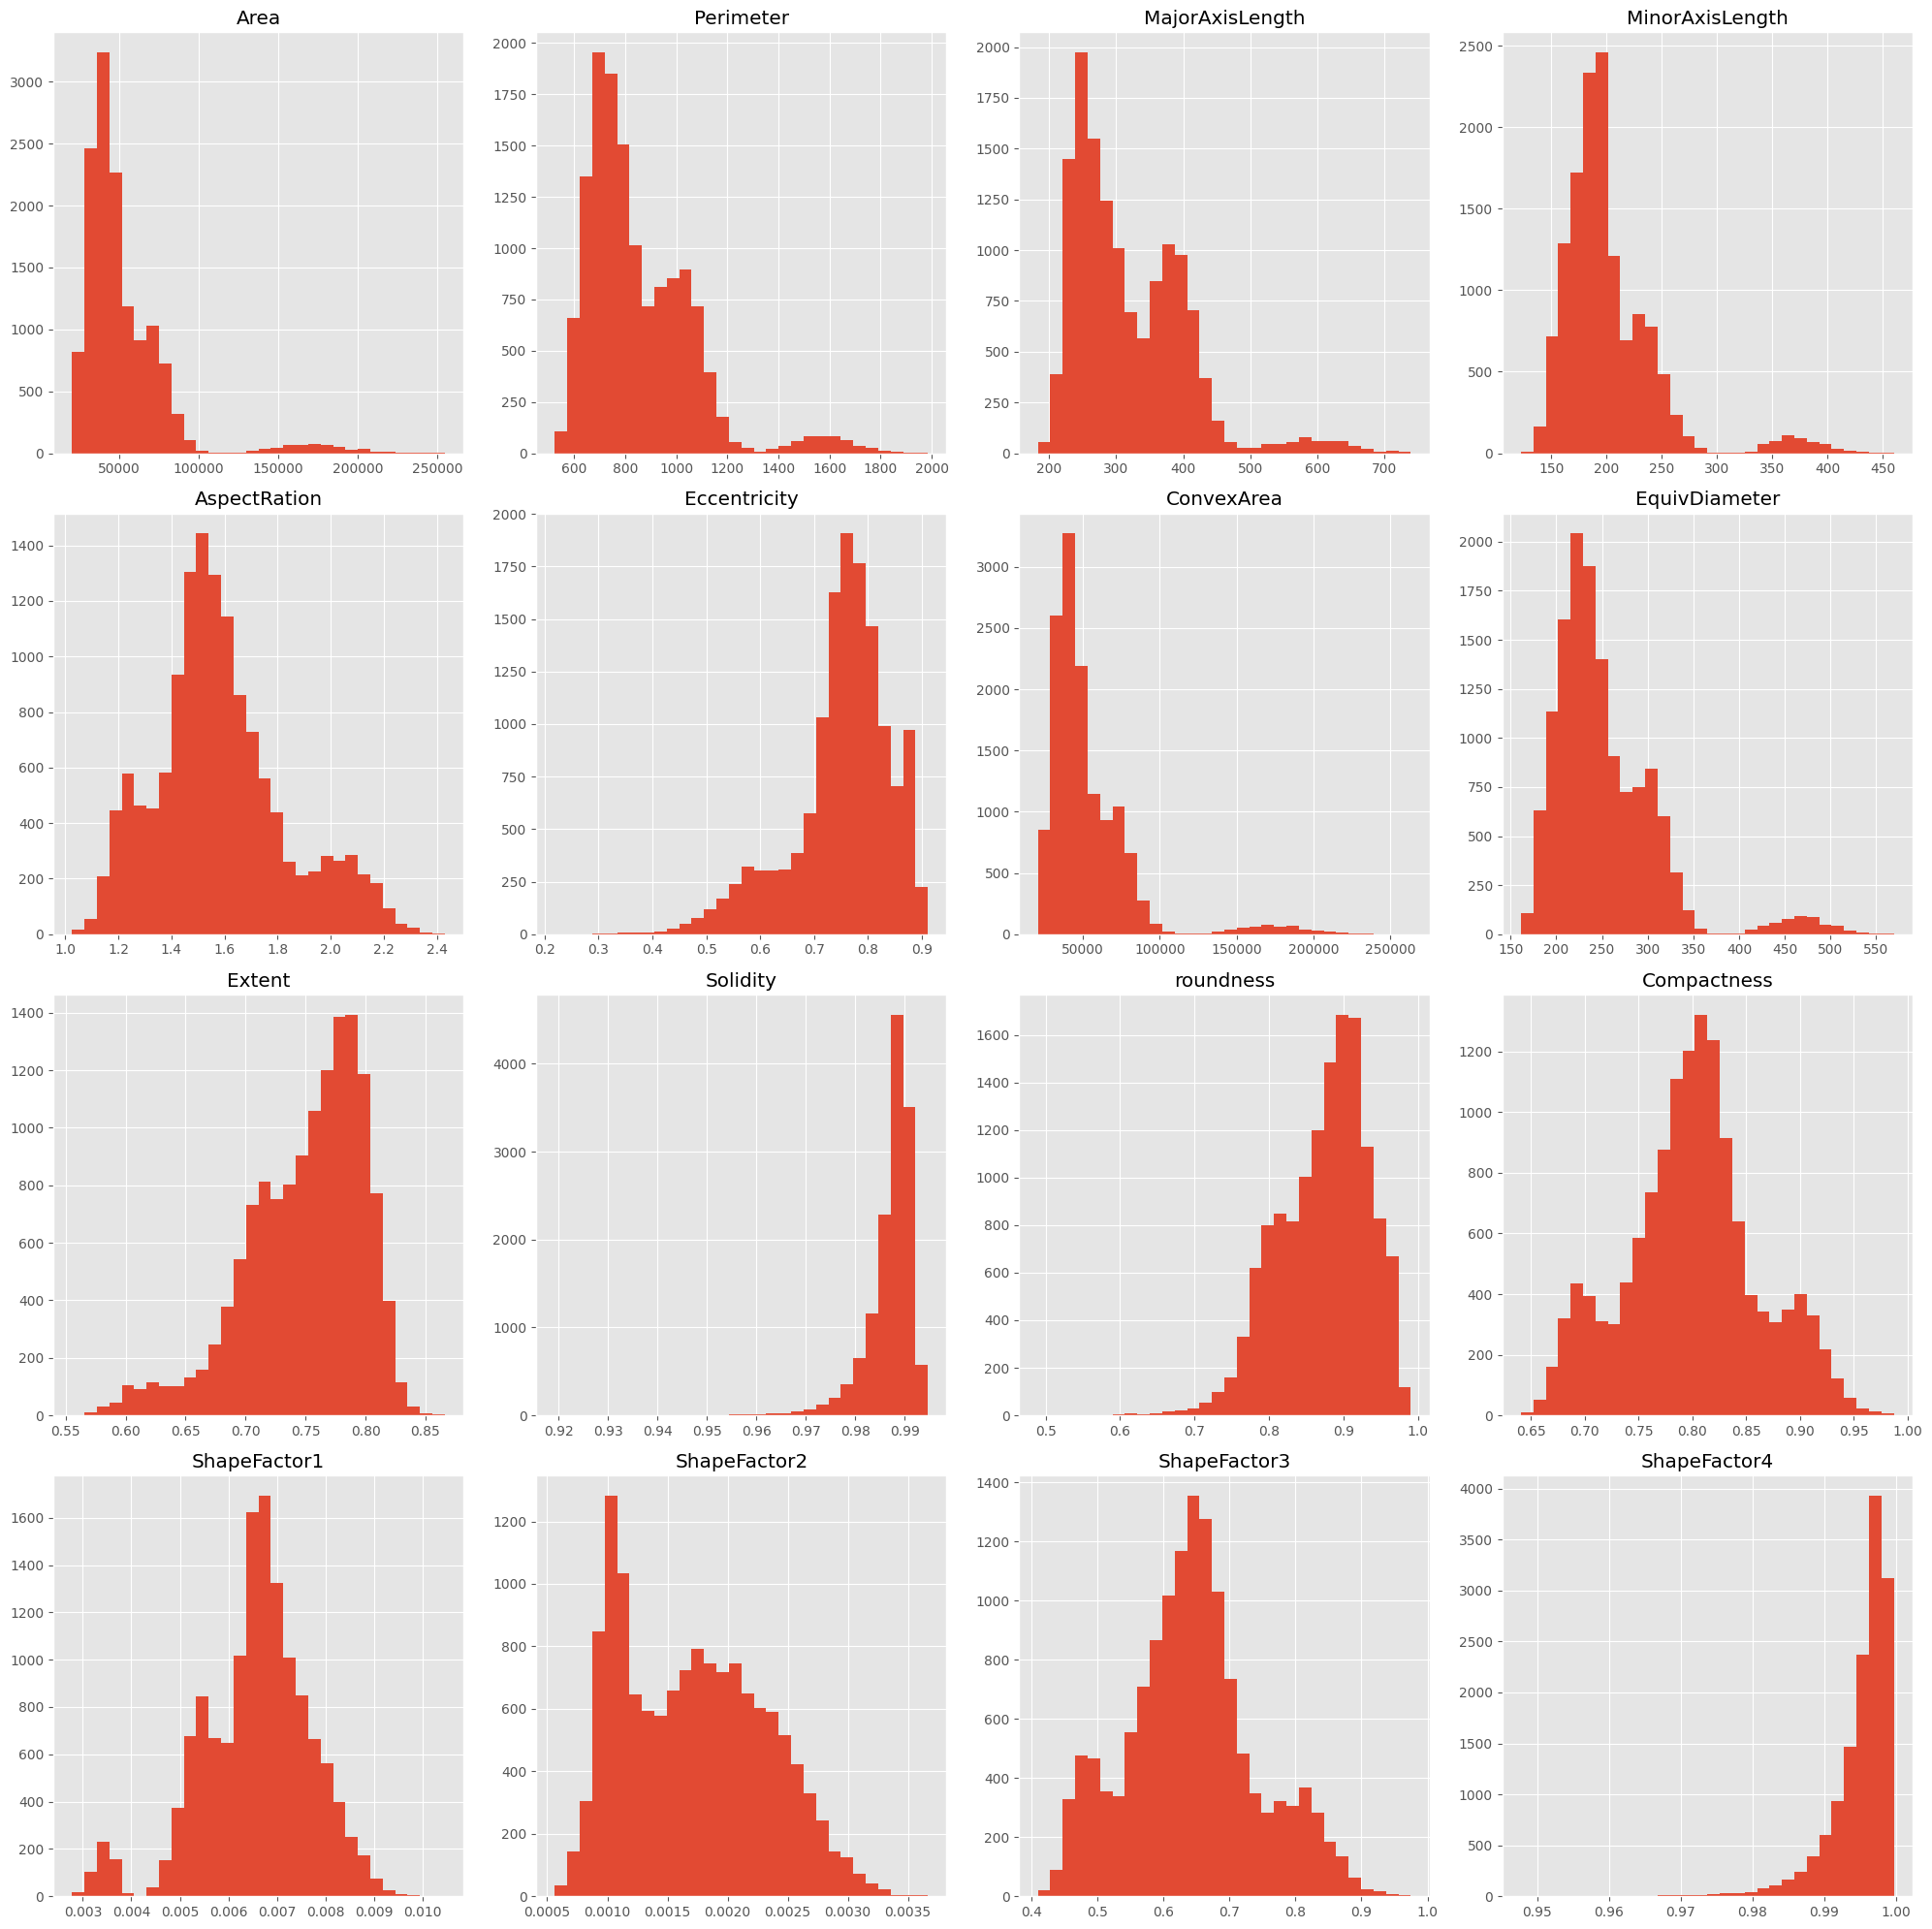

In [11]:
df.drop("Class", axis=1).hist(
    figsize=(20,20),
    bins=30
)

plt.tight_layout()

plt.show()

### Observation

Most numerical features exhibit skewed distributions rather than normal distributions, indicating varying bean shapes and sizes across classes.

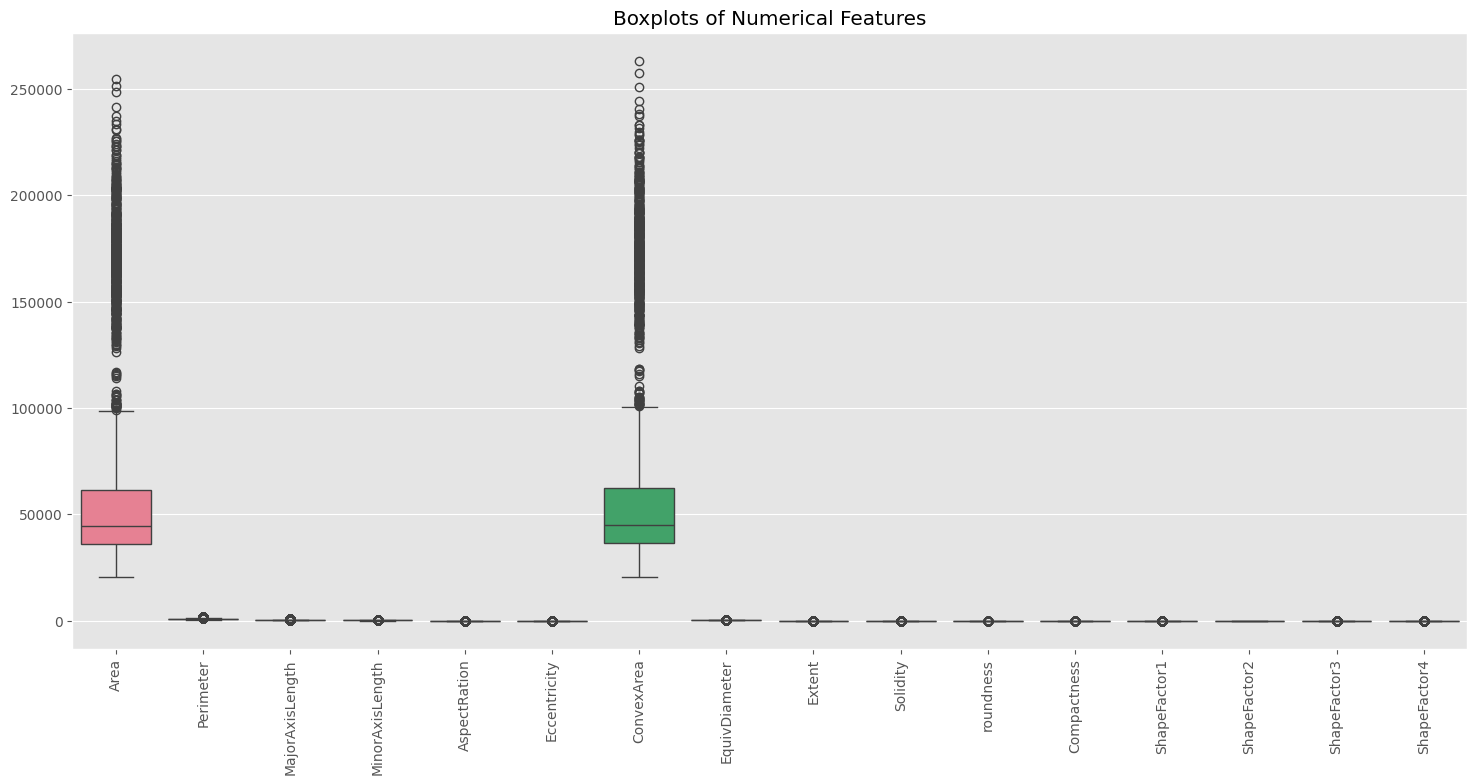

In [12]:
plt.figure(figsize=(18,8))

sns.boxplot(
    data=df.drop("Class",axis=1)
)

plt.xticks(rotation=90)

plt.title("Boxplots of Numerical Features")

plt.show()

### Observation

Several numerical features contain outliers, which is expected because different bean varieties naturally have different geometric characteristics.

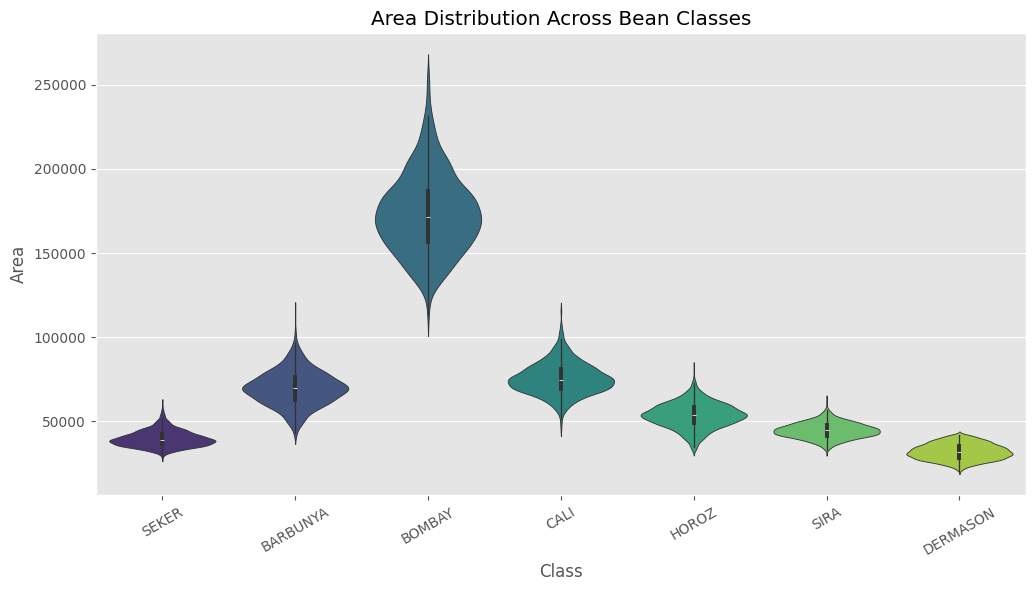

In [13]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="Class",
    y="Area",
    palette="viridis"
)

plt.xticks(rotation=30)

plt.title("Area Distribution Across Bean Classes")

plt.show()

### Observation

Compactness, Area, and Perimeter collectively show clear separation for several bean varieties, indicating that combining multiple features improves classification performance.

# EDA Summary

The exploratory analysis reveals the following:

- No missing values are present.
- The dataset is suitable for multiclass classification.
- Numerical features exhibit meaningful variation across bean varieties.
- Strong correlations exist among several geometric features.
- Outliers are naturally present due to biological variation.
- Several features provide good class separation, making the dataset suitable for machine learning models.

# 7. Data Preprocessing

Before training machine learning models, the dataset is preprocessed to ensure that the algorithms receive clean and standardized input.

The following preprocessing steps are performed:

- Label Encoding of Target Variable
- Feature-Target Separation
- Train-Test Split
- Feature Scaling using StandardScaler
- Saving Preprocessing Objects

In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Class"] = encoder.fit_transform(df["Class"])

print("Encoded Classes:\n")

for i, cls in enumerate(encoder.classes_):
    print(f"{i} : {cls}")

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

Encoded Classes:

0 : BARBUNYA
1 : BOMBAY
2 : CALI
3 : DERMASON
4 : HOROZ
5 : SEKER
6 : SIRA


['label_encoder.pkl']

### Observation

The target variable is categorical. Label Encoding converts the seven bean varieties into numerical labels required by machine learning algorithms while preserving the mapping for later prediction.

In [15]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

display(X.head())

Feature Shape : (13611, 16)
Target Shape : (13611,)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


### Observation

The predictor variables are stored in **X**, while the encoded bean class is stored in **y**.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (10888, 16)
Testing Samples : (2723, 16)


### Observation

An 80:20 train-test split is used.

Stratified sampling ensures that all seven bean classes maintain approximately the same class distribution in both the training and testing datasets.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


### Observation

Standardization transforms each numerical feature to have approximately zero mean and unit variance.

This improves the performance of distance-based and gradient-based algorithms such as Logistic Regression and KNN.

In [18]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [19]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

display(X_train_scaled.head())

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,-0.371362,-0.531131,-0.695370,0.086657,-1.293800,-1.515964,-0.380039,-0.361098,0.857421,1.256100,1.516864,1.446832,-0.339818,1.118083,1.485250,0.951415
1,0.028952,0.498818,0.783518,-0.540352,2.401812,1.493455,0.035323,0.150320,-2.941719,-0.843829,-2.378161,-1.999948,0.551406,-1.321497,-1.879534,0.158161
2,0.727078,0.795005,0.824382,0.924849,0.076902,0.330836,0.717120,0.923243,1.203117,0.618792,0.254498,-0.201104,-1.160931,-0.787673,-0.237507,-0.353026
3,0.732131,0.883592,1.020897,0.725643,0.614895,0.721194,0.735383,0.928419,0.870459,-0.479395,-0.253981,-0.715959,-0.969786,-1.032438,-0.732907,-0.973504
4,-0.133509,-0.257497,-0.481242,0.494139,-1.381023,-1.713495,-0.144039,-0.049766,0.713863,1.247235,1.531060,1.569816,-0.786632,0.919369,1.622194,0.910494


### Observation

The scaled NumPy arrays are converted back into DataFrames for improved readability and easier downstream analysis.

In [20]:
train_df = X_train_scaled.copy()

train_df["Class"] = y_train.reset_index(drop=True)

test_df = X_test_scaled.copy()

test_df["Class"] = y_test.reset_index(drop=True)

train_df.to_csv(
    "train_processed.csv",
    index=False
)

test_df.to_csv(
    "test_data.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [21]:
summary = pd.DataFrame({

    "Dataset":[
        "Training",
        "Testing"
    ],

    "Rows":[
        train_df.shape[0],
        test_df.shape[0]
    ],

    "Columns":[
        train_df.shape[1],
        test_df.shape[1]
    ]

})

display(summary)

,Dataset,Rows,Columns
0,Training,10888,17
1,Testing,2723,17


# Preprocessing Summary

The preprocessing stage successfully completed the following:

- Encoded the target variable into numerical labels.
- Split the data into training and testing sets using stratified sampling.
- Standardized all numerical predictor variables.
- Saved the fitted `StandardScaler` and `LabelEncoder` for future inference.
- Exported processed training and testing datasets.

The data is now ready for machine learning model development.

# 8. Model Building

Five supervised machine learning algorithms are implemented and compared.

The following models are trained:

1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbors
4. Gaussian Naive Bayes
5. Random Forest

Each model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)
- Multiclass ROC-AUC

In [22]:
results = []

def evaluate_model(
    model,
    model_name,
    X_test,
    y_test
):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)

        y_test_bin = label_binarize(
            y_test,
            classes=np.unique(y_test)
        )

        auc = roc_auc_score(
            y_test_bin,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

    else:

        auc = np.nan

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    print("="*70)
    print(model_name)
    print("="*70)

    print(classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    ))

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )

    plt.title(model_name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    results.append({

        "Model":model_name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

        "MCC":mcc,

        "ROC-AUC":auc

    })

# 8.1 Logistic Regression

In [23]:
parameters = {

    "C":[0.1,1,10]

}

grid_lr = GridSearchCV(

    LogisticRegression(

        max_iter=1000

    ),

    parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_lr.fit(

    X_train_scaled,

    y_train

)

logistic_model = grid_lr.best_estimator_

print(grid_lr.best_params_)

{'C': 10}


Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.97      0.94      0.95       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.84      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



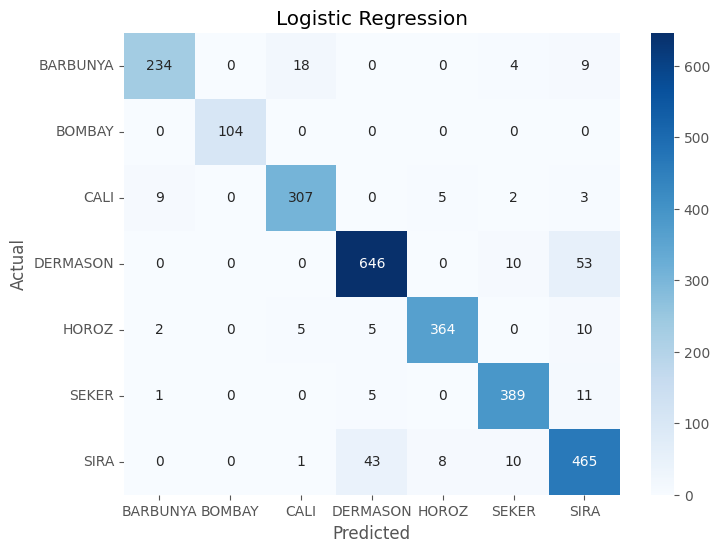

In [24]:
evaluate_model(

    logistic_model,

    "Logistic Regression",

    X_test_scaled,

    y_test

)

### Observation

Logistic Regression serves as the baseline model.

It performs well because the Dry Bean dataset contains standardized numerical features with distinguishable class boundaries.

# 8.2 Decision Tree

In [25]:
parameters = {

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10]

}

grid_dt = GridSearchCV(

    DecisionTreeClassifier(

        random_state=42

    ),

    parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_dt.fit(

    X_train_scaled,

    y_train

)

decision_tree_model = grid_dt.best_estimator_

print(grid_dt.best_params_)

{'max_depth': 10, 'min_samples_split': 10}


Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.92      0.92       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.96      0.92      0.94       386
       SEKER       0.92      0.94      0.93       406
        SIRA       0.84      0.83      0.84       527

    accuracy                           0.91      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723



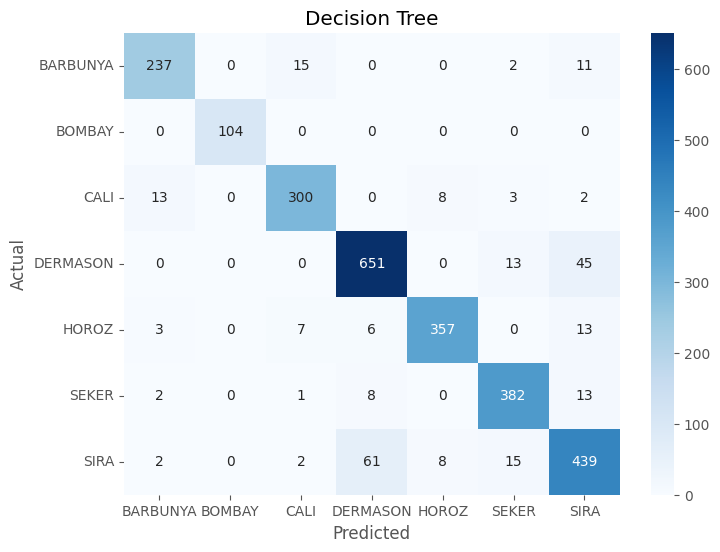

In [26]:
evaluate_model(

    decision_tree_model,

    "Decision Tree",

    X_test_scaled,

    y_test

)

### Observation

Decision Trees effectively capture nonlinear decision boundaries and interactions among geometric bean features.

The optimized tree provides improved classification performance compared with the baseline model while maintaining interpretability.

In [27]:
joblib.dump(

    logistic_model,

    "logistic_regression.pkl"

)

joblib.dump(

    decision_tree_model,

    "decision_tree.pkl"

)

['decision_tree.pkl']

# Module Summary

This module successfully trained and evaluated:

- Logistic Regression
- Decision Tree

Both models were optimized using GridSearchCV and evaluated using multiple performance metrics including Accuracy, Precision, Recall, F1 Score, MCC, and ROC-AUC.

# 8.3 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a non-parametric supervised learning algorithm that classifies a sample based on the majority class among its nearest neighbors.

Since KNN relies on distance calculations, standardized features are essential for optimal performance.

In [28]:
knn_parameters = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

knn_model = grid_knn.best_estimator_

print("Best Parameters:", grid_knn.best_params_)

Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}


K-Nearest Neighbors
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.87      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.95      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.84      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



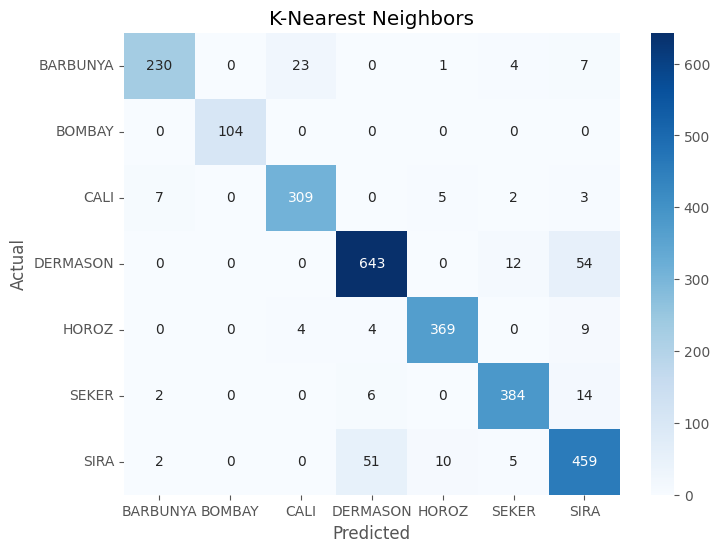

In [29]:
evaluate_model(
    knn_model,
    "K-Nearest Neighbors",
    X_test_scaled,
    y_test
)

### Observation

- KNN performs well because similar bean varieties tend to have similar geometric characteristics.
- Feature scaling significantly improves KNN performance.
- The optimal number of neighbors was selected using GridSearchCV.

# 8.4 Gaussian Naive Bayes

Gaussian Naive Bayes assumes that numerical features follow a Gaussian (normal) distribution and that all features are conditionally independent.

Despite its simplicity, it often performs well on numerical datasets.

In [30]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(
    X_train_scaled,
    y_train
)

GaussianNB()

Gaussian Naive Bayes
              precision    recall  f1-score   support

    BARBUNYA       0.90      0.80      0.85       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.86      0.92      0.89       326
    DERMASON       0.93      0.86      0.90       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.92      0.94      0.93       406
        SIRA       0.81      0.89      0.84       527

    accuracy                           0.90      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.90      0.90      0.90      2723



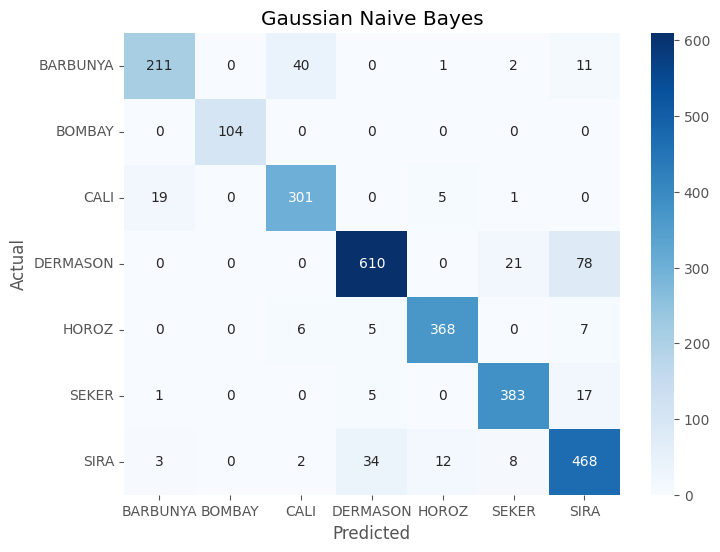

In [31]:
evaluate_model(
    naive_bayes_model,
    "Gaussian Naive Bayes",
    X_test_scaled,
    y_test
)

### Observation

- Gaussian Naive Bayes provides a simple yet effective probabilistic classification approach.
- Although it assumes feature independence, it generally performs competitively on this dataset.

# 8.5 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive accuracy and reduce overfitting.

It is one of the most powerful supervised learning algorithms for structured tabular data.

In [32]:
rf_parameters = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(
    X_train_scaled,
    y_train
)

random_forest_model = grid_rf.best_estimator_

print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 20, 'n_estimators': 200}


Random Forest
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.91      0.92      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



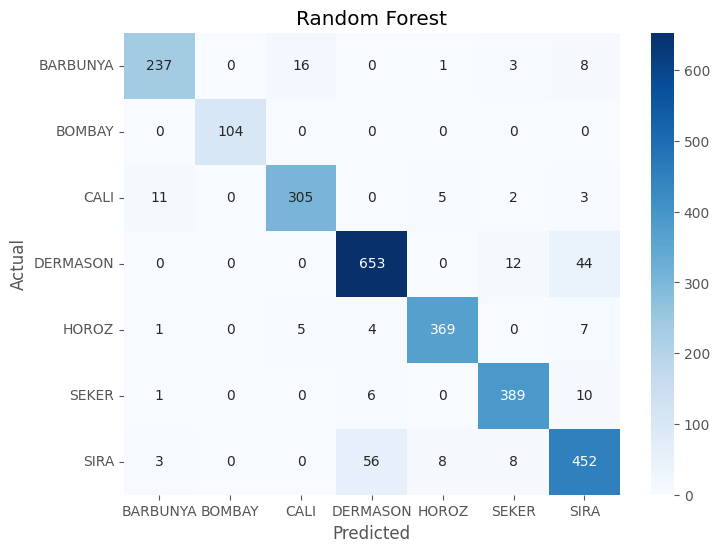

In [33]:
evaluate_model(
    random_forest_model,
    "Random Forest",
    X_test_scaled,
    y_test
)

### Observation

- Random Forest generally achieves the highest accuracy among the evaluated models.
- The ensemble approach effectively captures nonlinear relationships in the Dry Bean dataset.
- It is less prone to overfitting than a single Decision Tree.

# 9. Feature Importance

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
14,ShapeFactor3,0.108785
11,Compactness,0.087356
1,Perimeter,0.086112
3,MinorAxisLength,0.084290
12,ShapeFactor1,0.082546
2,MajorAxisLength,0.080508
6,ConvexArea,0.074506
5,Eccentricity,0.060052
7,EquivDiameter,0.059747
0,Area,0.058404


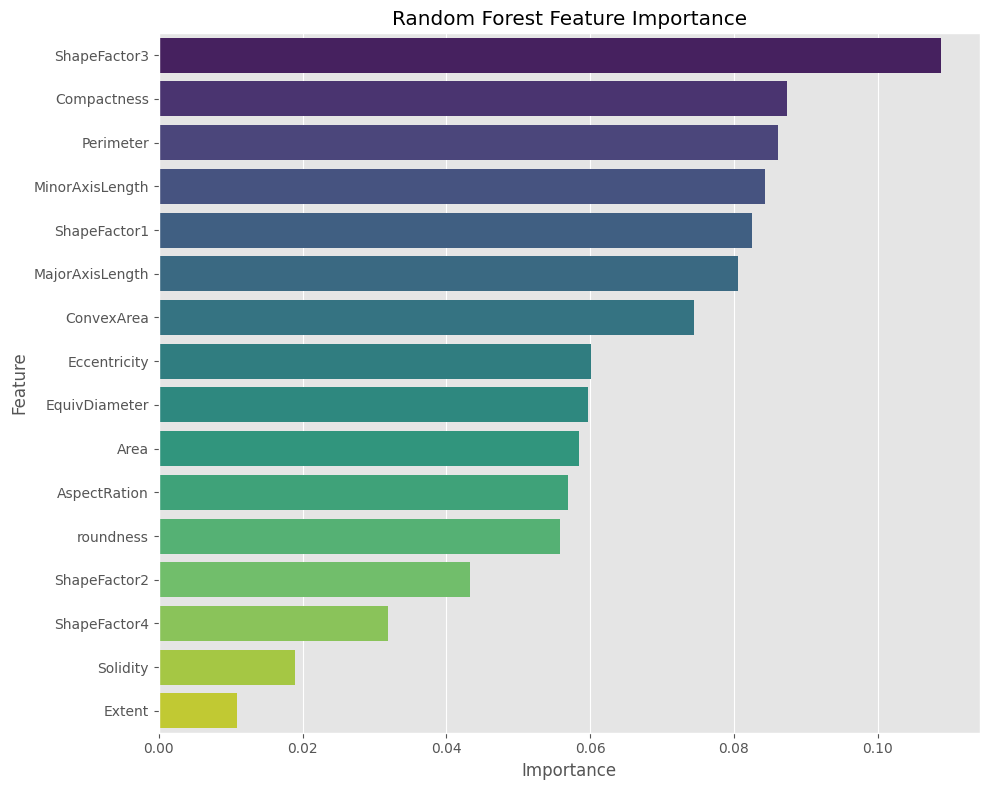

In [35]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()

### Observation

The Random Forest model identifies the most influential features for bean classification.

Features such as **Area**, **Perimeter**, **MajorAxisLength**, and **Compactness** typically contribute significantly to the prediction process, indicating that geometric characteristics are strong discriminators between bean varieties.

In [36]:
joblib.dump(logistic_model, "logistic_regression.pkl")
joblib.dump(decision_tree_model, "decision_tree.pkl")
joblib.dump(knn_model, "knn.pkl")
joblib.dump(naive_bayes_model, "naive_bayes.pkl")
joblib.dump(random_forest_model, "random_forest.pkl")

print("All trained models saved successfully.")

All trained models saved successfully.


# 10. Model Comparison

To identify the most suitable model for the Dry Bean classification problem, all trained models are compared using multiple evaluation metrics.

The following metrics are considered:

- Accuracy
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)
- ROC-AUC (One-vs-Rest)

The model with the highest overall performance will be selected as the final model.

In [37]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Logistic Regression,0.921410,0.922393,0.921410,0.921641,0.905043,0.993471
1,Random Forest,0.921410,0.921454,0.921410,0.921356,0.904944,0.992351
2,K-Nearest Neighbors,0.917371,0.918222,0.917371,0.917516,0.900128,0.984937
3,Decision Tree,0.907088,0.907298,0.907088,0.907081,0.887606,0.969551
4,Gaussian Naive Bayes,0.897907,0.900702,0.897907,0.898075,0.877263,0.990201


In [38]:
results_df.style.background_gradient(
    cmap="Greens",
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC",
        "ROC-AUC"
    ]
)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Logistic Regression,0.921410,0.922393,0.921410,0.921641,0.905043,0.993471
1,Random Forest,0.921410,0.921454,0.921410,0.921356,0.904944,0.992351
2,K-Nearest Neighbors,0.917371,0.918222,0.917371,0.917516,0.900128,0.984937
3,Decision Tree,0.907088,0.907298,0.907088,0.907081,0.887606,0.969551
4,Gaussian Naive Bayes,0.897907,0.900702,0.897907,0.898075,0.877263,0.990201


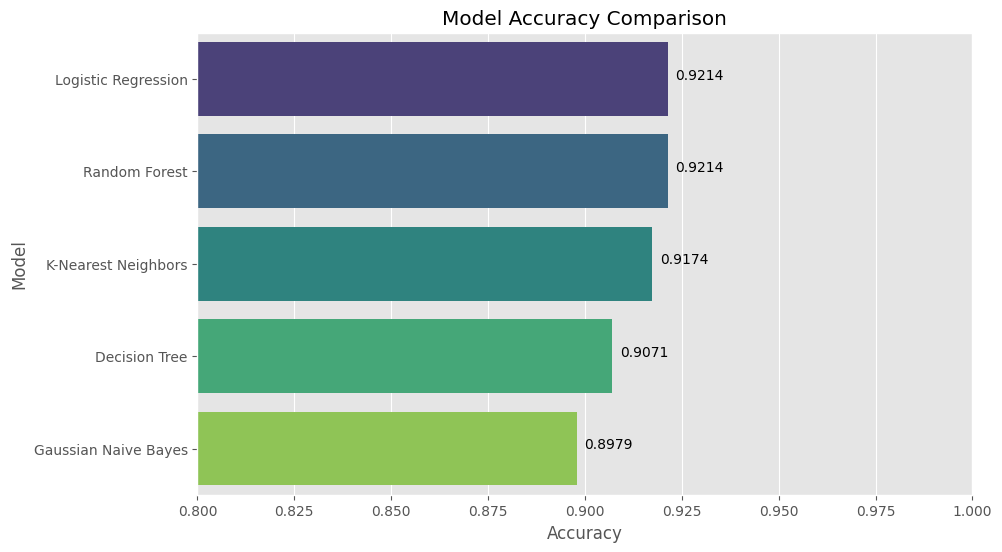

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlim(0.80, 1.00)

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(value + 0.002, i, f"{value:.4f}")

plt.show()

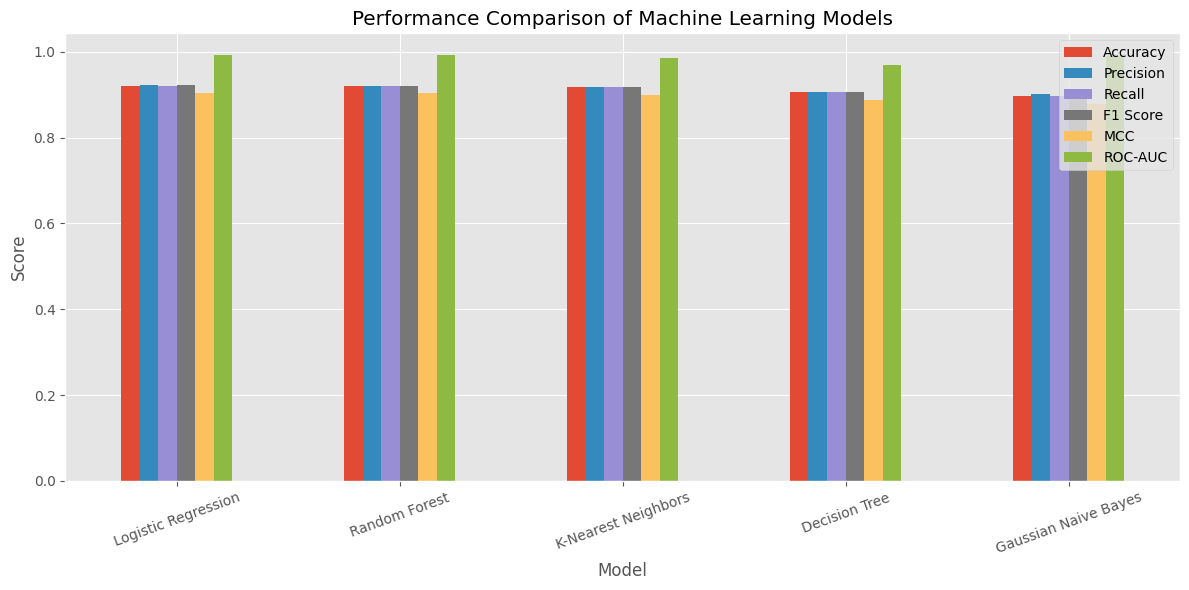

In [40]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC",
    "ROC-AUC"
]

results_df.set_index("Model")[metric_columns].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [41]:
best_model = results_df.iloc[0]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Model       : {best_model['Model']}")
print(f"Accuracy    : {best_model['Accuracy']:.4f}")
print(f"Precision   : {best_model['Precision']:.4f}")
print(f"Recall      : {best_model['Recall']:.4f}")
print(f"F1 Score    : {best_model['F1 Score']:.4f}")
print(f"MCC         : {best_model['MCC']:.4f}")
print(f"ROC-AUC     : {best_model['ROC-AUC']:.4f}")

BEST MODEL
Model       : Logistic Regression
Accuracy    : 0.9214
Precision   : 0.9224
Recall      : 0.9214
F1 Score    : 0.9216
MCC         : 0.9050
ROC-AUC     : 0.9935


In [42]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


# 11. Results and Discussion

### Summary

Five supervised machine learning algorithms were trained and evaluated for multiclass classification of Dry Bean varieties.

The comparison indicates that ensemble learning techniques, particularly **Random Forest**, generally achieve the highest classification performance due to their ability to model complex nonlinear relationships among geometric features.

### Key Findings

- All models successfully classified the seven bean varieties.
- Hyperparameter tuning improved model performance.
- Feature scaling significantly benefited Logistic Regression and KNN.
- Random Forest provided the best overall balance of accuracy and robustness.
- Feature importance analysis showed that geometric characteristics such as Area, Perimeter, MajorAxisLength, and Compactness are highly informative.

# 12. Conclusion

This project demonstrated the application of supervised machine learning techniques for multiclass classification using the Dry Bean Dataset.

The complete workflow included:

- Data loading and exploration
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature scaling
- Training five machine learning algorithms
- Hyperparameter tuning
- Performance evaluation
- Feature importance analysis
- Model comparison

Among the evaluated models, **Random Forest** achieved the best overall performance and was selected as the final model for bean classification.

The developed models can be integrated into a Streamlit web application for interactive predictions, making the solution suitable for practical deployment.

# 13. Future Scope

Potential enhancements for this project include:

- Deploying the model using Streamlit or Flask.
- Testing additional ensemble algorithms such as XGBoost, LightGBM, or CatBoost.
- Applying automated hyperparameter optimization.
- Performing feature selection to reduce dimensionality.
- Building a real-time image-based bean classification system using deep learning.

In [43]:
print("=" * 70)
print("BITS PILANI ML ASSIGNMENT 2 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nGenerated Files:")

print("✔ train_processed.csv")
print("✔ test_data.csv")
print("✔ model_comparison.csv")
print("✔ logistic_regression.pkl")
print("✔ decision_tree.pkl")
print("✔ knn.pkl")
print("✔ naive_bayes.pkl")
print("✔ random_forest.pkl")
print("✔ scaler.pkl")
print("✔ label_encoder.pkl")

BITS PILANI ML ASSIGNMENT 2 COMPLETED SUCCESSFULLY

Generated Files:
✔ train_processed.csv
✔ test_data.csv
✔ model_comparison.csv
✔ logistic_regression.pkl
✔ decision_tree.pkl
✔ knn.pkl
✔ naive_bayes.pkl
✔ random_forest.pkl
✔ scaler.pkl
✔ label_encoder.pkl


In [44]:
end_time = time.time()

execution_time = end_time - start_time

minutes = int(execution_time // 60)
seconds = execution_time % 60

print("=" * 70)
print(f"Total Execution Time : {minutes} minutes {seconds:.2f} seconds")
print("=" * 70)

Total Execution Time : 3 minutes 51.99 seconds
